In [1]:
import ast
import sys, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import dill
from configs.data_constants_config import ALPHA

import mlflow
import mlflow.sklearn
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, ConstantKernel, WhiteKernel
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score


In [2]:
#Data loading
path = '/home/isha/Desktop/Projects/03_Remaining_Useful_Life_Prediction/artifacts/'
X_train = pd.read_csv(os.path.join(path, 'X_train_proper.csv'))
y_train = pd.read_csv(os.path.join(path, 'y_train_proper.csv')).values.ravel()
X_cal = pd.read_csv(os.path.join(path, 'X_cal.csv'))
y_cal = pd.read_csv(os.path.join(path, 'y_cal.csv')).values.ravel()
X_test = pd.read_csv(os.path.join(path, 'X_test_processed.csv'))
y_test = pd.read_csv(os.path.join(path, 'y_test.csv')).values.ravel()

#Top 5 models after hyperparameter tuning
top_df = pd.read_csv(os.path.join(path, 'top2_gp_models.csv'))

print('Top model (ranked by RMSE - MAE - R square):')
display(top_df[['model','test_rmse','test_mae','test_r2','best_params']])

Top model (ranked by RMSE - MAE - R square):


,model,test_rmse,test_mae,test_r2,best_params
0,Gaussian Process,17.562538,12.220109,0.807928,"{'alpha': 0.5, 'kernel': Matern(length_scale=1..."


In [3]:
X_train_gp = X_train.copy()
y_train_gp = y_train.copy()

X_test_gp = X_test.copy()
y_test_gp = y_test.copy()

'''
#Downsampling method 1 - Discarded because it gives poor coverage, overconfident predictions and does not capture aleatoric uncertainty of sesnor data
if len(X_train_gp) > 2500:
    step = len(X_train_gp) // 2500
    X_train_gp = X_train_gp.iloc[::step].reset_index(drop=True)
    y_train_gp = y_train_gp[::step]

if len(X_test_gp) > 1000:
    step = len(X_test_gp) // 1000
    X_test_gp = X_test_gp.iloc[::step].reset_index(drop=True)
    y_test_gp = y_test_gp[::step]
'''


#Downsampling method 2 - Random sampling to reduce training size to 2500 samples
X_train_gp = X_train.sample(n=2500, random_state=42)
y_train_gp = y_train[X_train_gp.index]


'''
#Downsampling method 3 - Using landmark selection to reduce training size to 2500 samples
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=2500, random_state=42)
cluster_labels = kmeans.fit_predict(X_train)
X_train_gp = pd.DataFrame(kmeans.cluster_centers_,columns=X_train.columns)
y_train_gp = np.array([y_train[cluster_labels == i].mean()for i in range(2500)])

print("Training samples:", len(X_train))
print("Unique samples:", len(np.unique(X_train, axis=0)))
print("Requested clusters:", 2500)
print("Clusters actually used:", len(np.unique(cluster_labels)))

'''

'\n#Downsampling method 3 - Using landmark selection to reduce training size to 2500 samples\nfrom sklearn.cluster import KMeans\n\nkmeans = KMeans(n_clusters=2500, random_state=42)\ncluster_labels = kmeans.fit_predict(X_train)\nX_train_gp = pd.DataFrame(kmeans.cluster_centers_,columns=X_train.columns)\ny_train_gp = np.array([y_train[cluster_labels == i].mean()for i in range(2500)])\n\nprint("Training samples:", len(X_train))\nprint("Unique samples:", len(np.unique(X_train, axis=0)))\nprint("Requested clusters:", 2500)\nprint("Clusters actually used:", len(np.unique(cluster_labels)))\n\n'

In [4]:
print(f"Training on {len(X_train_gp)} samples")
print(f"Testing  on {len(X_test_gp)} samples")

Training on 2500 samples
Testing  on 100 samples


In [5]:
X_test_gp

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10
0,-2.456195,-0.615238,-1.040229,0.065061,0.256364,0.335176,-0.785185,0.363242,0.359278,-0.410717
1,-0.617189,-1.297868,-0.158286,-1.031248,-0.883495,-0.273285,0.215997,0.171677,0.083331,0.386818
2,1.550791,-1.308515,-0.462771,0.768613,0.799181,-0.499910,-0.232935,-1.525689,0.041534,0.538966
3,1.344928,-0.749913,0.112369,0.770123,0.009515,0.714008,-0.563936,0.947797,-0.758266,-0.346071
4,0.185203,-1.181934,-0.015140,0.922549,-0.396479,1.069036,0.149774,-0.854099,0.523442,0.755715
...,...,...,...,...,...,...,...,...,...,...
95,-3.496422,0.538353,0.981124,-0.418432,0.107825,0.622888,0.208019,-0.020923,-0.380753,-0.229001
96,-0.303271,1.066474,-1.521436,0.770306,-0.283398,0.762759,-0.574596,0.860648,0.487266,0.386694
97,0.664410,0.059385,1.249260,0.523478,0.443648,0.762129,-0.395147,-0.492308,0.439503,0.328135
98,-3.637811,0.716120,0.143667,-0.272672,-0.650988,-0.222952,-0.229493,0.066639,0.398573,-0.076626


In [6]:
#Tell MLflow the name of your overall project/experiment
mlflow.set_experiment("RUL_Prediction_Downsampling_method_2")


alphas_to_test = [1e-10, 1e-5, 1e-2, 1e-1]
nus_to_test = [2.5]
scales_to_test = [[0.5] * 10, [1.0] * 10,  [2.0] * 10]


#Tuning loop
for current_alpha in alphas_to_test:
    for current_nu in nus_to_test:
        for initial_scales in scales_to_test:
            
            #Start the MLflow run INSIDE the loop
            with mlflow.start_run():
                
                #1. Log Parameters for THIS specific loop iteration
                mlflow.log_param("alpha", current_alpha)
                mlflow.log_param("matern_nu", current_nu)
                # MLflow prefers strings or numbers for parameters, so we convert the list to a string
                mlflow.log_param("length_scale", str(initial_scales)) 

                kernel = (ConstantKernel(constant_value = 100.0) #, constant_value_bounds=(1.0, 1e5)) 
                            * Matern(length_scale = initial_scales, nu=current_nu) # length_scale_bounds=(1e-2, 1e3), nu=current_nu)
                            + WhiteKernel(noise_level = 1.0, noise_level_bounds = (1e-3, 1e3)))

                
                #2. Train the Model
                gp_model = GaussianProcessRegressor(
                    kernel = kernel,
                    alpha = current_alpha, 
                    n_restarts_optimizer = 5,
                    normalize_y = True,
                    random_state = 42 
                )

                gp_model.fit(X_train_gp, y_train_gp) 
                
                #3. Predict with Uncertainty
                y_pred, sigma = gp_model.predict(X_test_gp, return_std=True)
                
                #4. Calculate All Metrics
                rmse = np.sqrt(np.mean((y_test_gp - y_pred) ** 2))
                mae = np.mean(np.abs(y_test_gp - y_pred))
                r2 = r2_score(y_test_gp, y_pred)
                
                z_score = 1.96
                lower_bound = y_pred - (z_score * sigma)
                upper_bound = y_pred + (z_score * sigma)
                mean_interval_width = np.mean(upper_bound - lower_bound)
                coverage = np.mean((y_test_gp >= lower_bound) & (y_test_gp <= upper_bound)) 
                
                #5. Log Metrics for THIS specific run
                mlflow.log_metric("rmse", rmse)
                mlflow.log_metric("mae", mae)
                mlflow.log_metric("r2", r2)
                mlflow.log_metric("mpiw_width", mean_interval_width)
                mlflow.log_metric("picp_coverage", coverage * 100)
                
                #6. Optional: Log the model
                #mlflow.sklearn.log_model(gp_model, "gp_rul_model")
                
                # Print terminal summary so you can watch progress
                print("="*60)
                print(f"Alpha: {current_alpha} | Nu: {current_nu} | Length scale: {initial_scales[0]}")
                print(f"Summary of the run:")
                print("-"*60)
                print(f"Accuracy Metrics:")
                print(f"RMSE: {rmse:.4f}")
                print(f"MAE:  {mae:.4f}")
                print(f"R2:   {r2:.4f}")
                print("-"*60)
                print(f"Uncertainty Metrics (95% CI):")
                print(f"Coverage: {coverage*100:.2f}%")
                print(f"Mean Width: {mean_interval_width:.4f}")
                print("="*60)
                print("\n")
                
print("\nAll hyperparameter combinations have been tracked in MLflow!")

Alpha: 1e-10 | Nu: 2.5 | Length scale: 0.5
Summary of the run:
------------------------------------------------------------
Accuracy Metrics:
RMSE: 17.1936
MAE:  11.7987
R2:   0.8159
------------------------------------------------------------
Uncertainty Metrics (95% CI):
Coverage: 94.00%
Mean Width: 70.6129


Alpha: 1e-10 | Nu: 2.5 | Length scale: 1.0
Summary of the run:
------------------------------------------------------------
Accuracy Metrics:
RMSE: 17.1935
MAE:  11.7987
R2:   0.8159
------------------------------------------------------------
Uncertainty Metrics (95% CI):
Coverage: 94.00%
Mean Width: 70.6128


Alpha: 1e-10 | Nu: 2.5 | Length scale: 2.0
Summary of the run:
------------------------------------------------------------
Accuracy Metrics:
RMSE: 17.1943
MAE:  11.7989
R2:   0.8159
------------------------------------------------------------
Uncertainty Metrics (95% CI):
Coverage: 94.00%
Mean Width: 70.6159


Alpha: 1e-05 | Nu: 2.5 | Length scale: 0.5
Summary of the run

# Using the best model
The best model is chosen where coverage is > 90%,the average prediction width is low and the RMSE error is least. 
This corresponds to GP with the following hyperparameters:
1. $\alpha =$ 0.01
2. Length scale $l =$ 0.5
3. $\nu =$ 2.5

In [7]:
l = [0.5]*10
kernel = (ConstantKernel(constant_value = 100.0) 
                            * Matern(length_scale = l, nu = 2.5) # length_scale_bounds=(1e-2, 1e3))
                            + WhiteKernel(noise_level = 1.0, noise_level_bounds = (1e-3, 1e3)))

                
                
gp_model = GaussianProcessRegressor(
                    kernel = kernel,
                    alpha = 0.01, 
                    n_restarts_optimizer = 5,
                    normalize_y = True,
                    random_state = 42 
                )


In [ ]:
gp_model.fit(X_train_gp, y_train_gp)

,kernel,10**2 * Mater...noise_level=1)
,alpha,0.01
,optimizer,'fmin_l_bfgs_b'
,n_restarts_optimizer,5
,normalize_y,True
,copy_X_train,True
,n_targets,None
,random_state,42
,kernel__k1,"10**2 * Mater... 0.5], nu=2.5)"
,kernel__k2,WhiteKernel(noise_level=1)
,kernel__k1__k1,10**2


## Plot 1: Point predictions + intervals 

In [12]:
from scipy.stats import norm

z = 1.96
y_pred, y_std = gp_model.predict(X_test_gp, return_std = True)

# 90% predictive interval
lower = y_pred - z * y_std
upper = y_pred + z * y_std

coverage = np.mean((y_test_gp >= lower) & (y_test_gp <= upper))*100
avg_width = np.mean(upper - lower)

print(f"Empirical coverage: {coverage:.3f}")
print(f"Average width: {avg_width:.3f}")

Empirical coverage: 93.000
Average width: 68.710


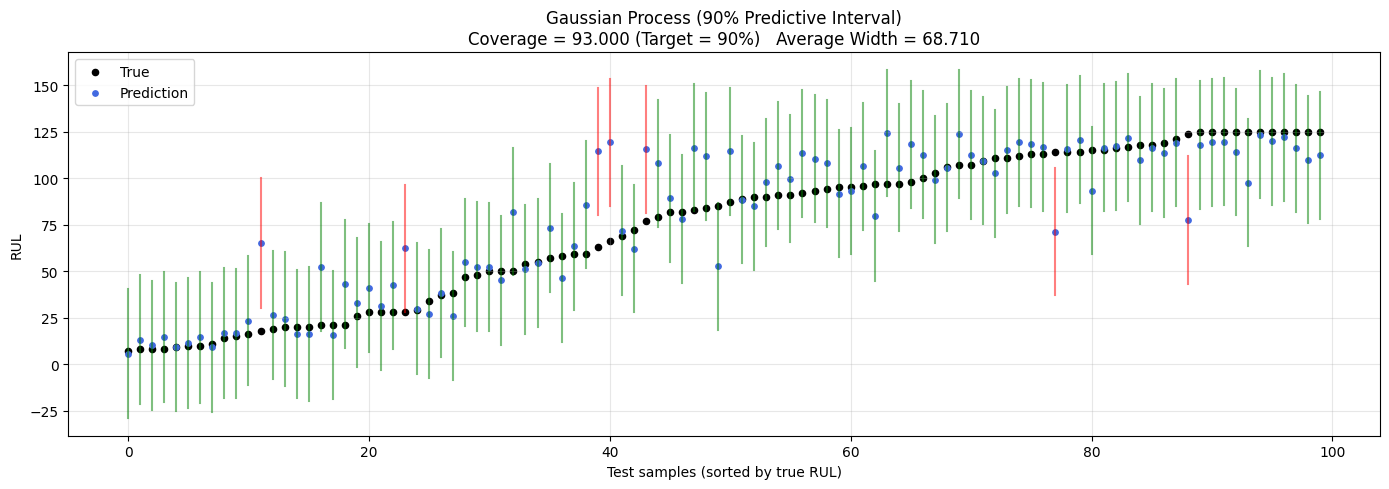

In [13]:
MAX_POINTS = 80

sort_idx = np.argsort(y_test_gp)
step = max(1, len(y_test_gp) // MAX_POINTS)

idx = sort_idx[::step]

y_true = y_test_gp[idx]
y_hat = y_pred[idx]

lo = lower[idx]
hi = upper[idx]

covered = (y_true >= lo) & (y_true <= hi)

x_pos = np.arange(len(idx))

fig, ax = plt.subplots(figsize=(14, 5))

for xi, l, h, cov in zip(x_pos, lo, hi, covered):

    ax.plot(
        [xi, xi],
        [l, h],
        color='green' if cov else 'red',
        linewidth=1.5,
        alpha=0.5
    )

ax.scatter(
    x_pos,
    y_true,
    color='black',
    s=20,
    label='True'
)

ax.scatter(
    x_pos,
    y_hat,
    color='royalblue',
    s=15,
    label='Prediction'
)

ax.set_xlabel("Test samples (sorted by true RUL)")
ax.set_ylabel("RUL")

ax.set_title(
    f"Gaussian Process (90% Predictive Interval)\n"
    f"Coverage = {coverage:.3f} (Target = 90%)   "
    f"Average Width = {avg_width:.3f}"
)

ax.grid(alpha=0.3)
ax.legend()

plt.tight_layout()

plt.savefig(
    os.path.join(path, "gp_prediction_intervals.png"),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

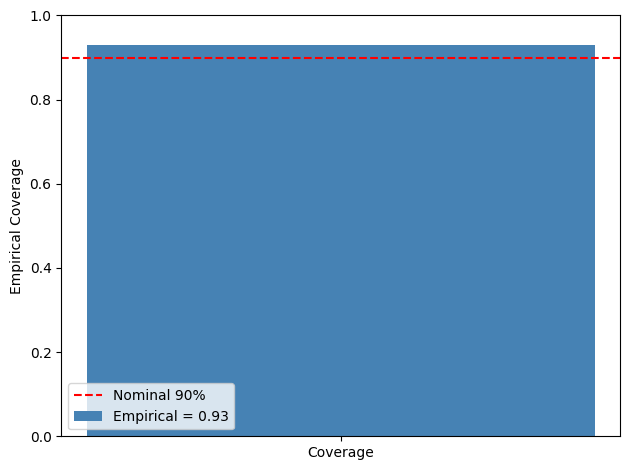

In [21]:
NOMINAL = (1 - ALPHA)

plt.axhline(NOMINAL, color="red", linestyle="--", label="Nominal 90%")
plt.bar([0], [coverage / 100], width=0.5, color="steelblue", label=rf"Empirical = {coverage/100}")

plt.xticks([0], ["Coverage"])
plt.ylabel("Empirical Coverage")
plt.ylim(0, 1)
plt.legend()
plt.tight_layout()

plt.savefig(
    os.path.join(path, "gp_empirical_coverage.png"),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [23]:
summary = pd.DataFrame({
    "Model": ["Gaussian Process"],
    "Coverage": [coverage],
    "Average Interval Width": [avg_width]
})

display(summary)


,Model,Coverage,Average Interval Width
0,Gaussian Process,93.0,68.710102
